In [1]:
import os
BASE_DIR = os.path.abspath(os.path.join(os.path.dirname("."), ".."))
EXPORTS_DIR = f"{BASE_DIR}/_exports/05_trustworthiness_assessment"
os.makedirs(EXPORTS_DIR, exist_ok=True)

In [2]:
LOAD_ASSESSMENT = True
ASSESSMENT_PATH = "./_exports/df_trustworthiness.csv"

In [3]:
# load Basins
import pickle
from lilypond.basin import Basin
dataset_names = ['Moon', 'S-Curve', 'Swiss Roll', 'Iris', 'Glass', 'Mushroom', 'Cardio']
basins = []
for dataset_name in dataset_names:
	basin:Basin = pickle.load(open(f"./_exports/basin_{dataset_name}.pkl", 'rb'))
	basins.append(basin)

In [4]:
# caclulate trustworthiness across varying k neighborhood setting
import numpy as np
import pandas as pd
from _utils.som_evaluation import calc_som_trustworthiness_umatrix, calc_som_trustworthiness_umatrix_altered

k_candidates = np.arange(5, 50+1, 5)

if LOAD_ASSESSMENT:
	df_trustworthiness = pd.read_csv(ASSESSMENT_PATH, index_col=[0, 1])
	df_trustworthiness.columns = df_trustworthiness.columns.astype(int)
else:
	df_trustworthiness = pd.DataFrame(
		columns=k_candidates,
		index=pd.MultiIndex.from_product([dataset_names, ["M_baseline", "M_altered"]], names=["dataset", "metric"])
	)

	for dataset_name, basin in zip(dataset_names, basins):
		for k in k_candidates:
			print(dataset_name, k)
			df_trustworthiness.loc[(dataset_name, "M_baseline"), k] = calc_som_trustworthiness_umatrix(basin.som, basin.data, k)
			df_trustworthiness.loc[(dataset_name, "M_altered"), k] = calc_som_trustworthiness_umatrix_altered(basin.som, basin.data, k)

In [5]:
df_trustworthiness.style \
	.format(precision=4)

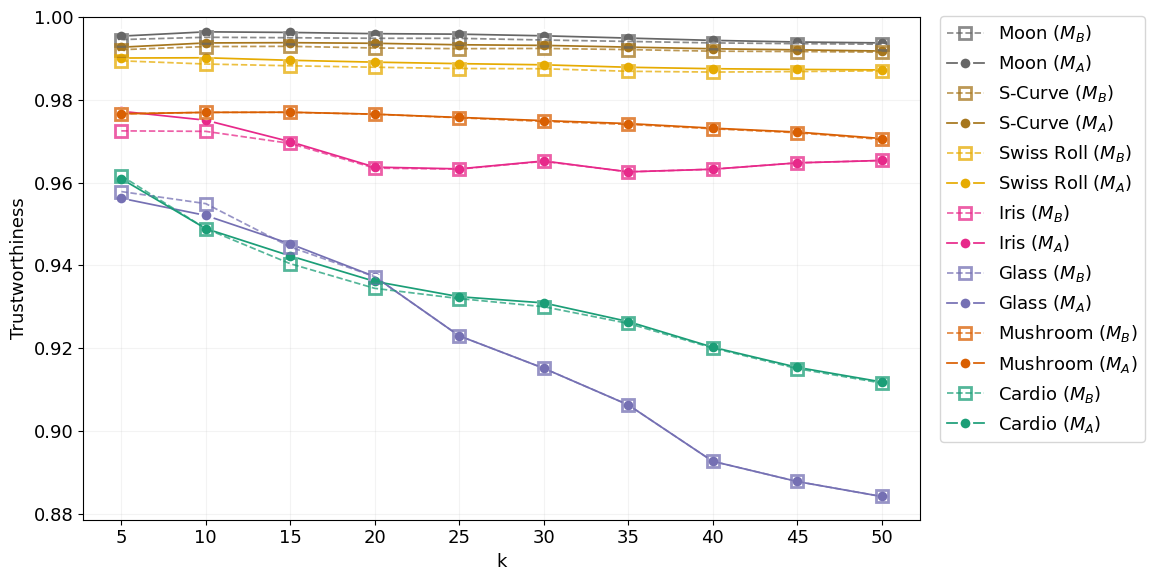

In [6]:
# plot trustworthiness chart
import matplotlib.pyplot as plt

plt.rc("font", size=13)

fig = plt.figure(figsize=(12, 6))
ax = plt.gca()

df_m_baseline = df_trustworthiness.xs("M_baseline", level='metric')
df_m_baseline.T.plot(kind='line', marker='s', markerfacecolor="none", markersize=9, markeredgewidth=2.0, linestyle="dashed", linewidth=1.25, cmap="Dark2_r", alpha=.75, zorder=3, ax=ax)

df_m_altered = df_trustworthiness.xs("M_altered", level='metric')
df_m_altered.T.plot(kind='line', marker='o', markersize=9, markeredgewidth=2.0, markeredgecolor="white", linestyle="solid", linewidth=1.25, cmap="Dark2_r", zorder=2, ax=ax)


ax.set_xlabel("k")
ax.set_ylabel("Trustworthiness")
plt.ylim(top=1.0)
plt.xticks(k_candidates)
plt.grid(alpha=.15)

handles, labels = ax.get_legend_handles_labels()
num_datasets = len(dataset_names)
handles_base = handles[:num_datasets]
handles_alt = handles[num_datasets:]
labels_base = labels[:num_datasets]
labels_alt = labels[num_datasets:]
new_handles = [h for pair in zip(handles_base, handles_alt) for h in pair]
new_labels = [l for pair in zip(list(map(lambda _: f"{_} ($M_B$)",labels_base)), list(map(lambda _: f"{_} ($M_A$)", labels_alt))) for l in pair]
plt.legend(handles=new_handles, labels=new_labels, loc="upper right", bbox_to_anchor=(1.28, 1.02))
plt.tight_layout()
plt.show()

In [7]:
# export fig
from _utils.export import export_figure
export_figure(fig, EXPORTS_DIR, "05_trustworthiness_chart.png")

Figure saved to `_exports` folder as `05_trustworthiness_chart.png`


---

In [8]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

mpl.rcParams['figure.dpi'] = 200.0
mpl.rcParams['savefig.dpi'] = 200.0

In [9]:
from _utils.som_knn import get_minimal_path_knn_inds, get_minimal_path_altered_knn_inds

def get_knn_projections(som, x_idx, k):
	som_weights = som.get_weights()
	som_shape = som_weights.shape[:2]
	som_winmap = som.win_map(basin.data, return_indices=True)
	som_distmap = som.distance_map(scaling="mean")

	x = basin.data[x_idx]

	knn_projection_inds = get_minimal_path_knn_inds(som, som_weights, som_winmap, som_distmap, som_shape, basin.data, x, x_idx, k)
	knn_projection_altered_inds = get_minimal_path_altered_knn_inds(som, som_weights, som_winmap, som_distmap, som_shape, basin.data, x, x_idx, k)

	return knn_projection_inds, knn_projection_altered_inds

In [10]:
selected_datasets = ["Iris", "Glass"]
selected_datasets_inds = list(map(lambda d: np.argwhere(np.array(dataset_names) == d)[0][0], selected_datasets))
selected_basins = np.array(basins)[selected_datasets_inds]
selected_sample_inds = [43, 103]
gaps = (0.225, 0.25)

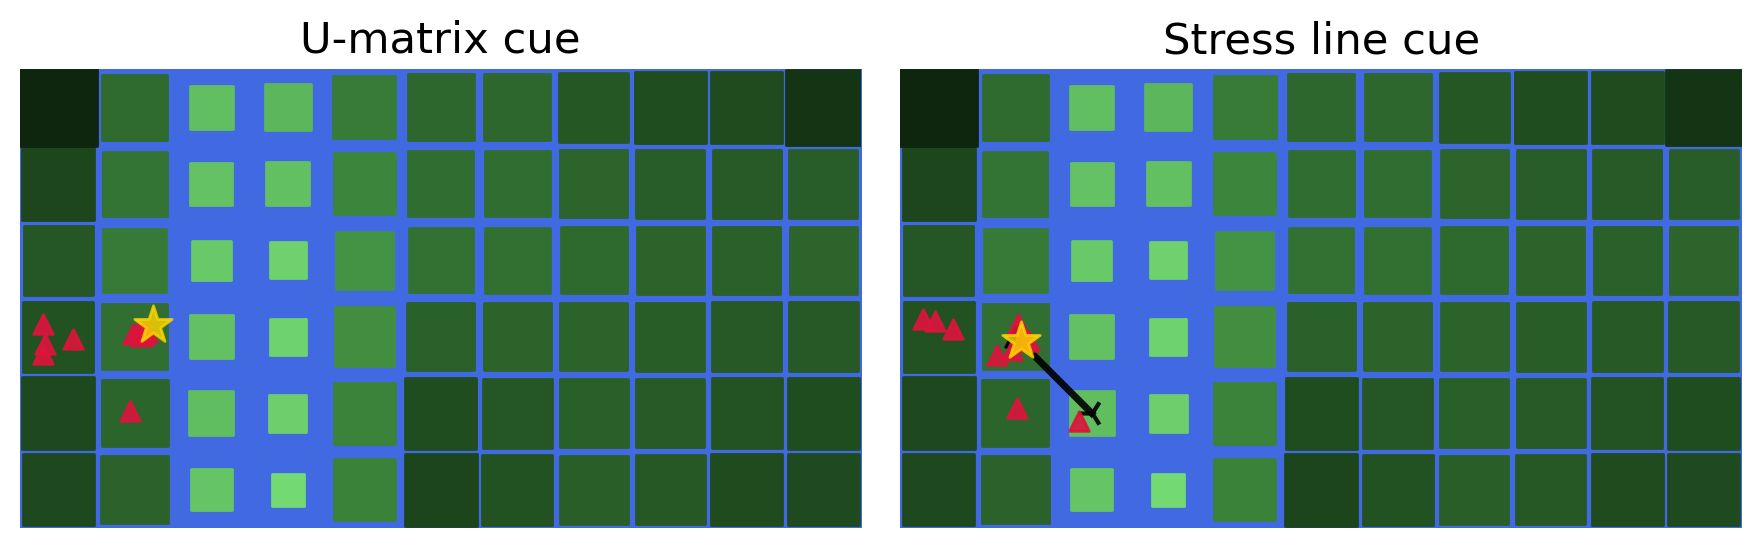

Figure saved to `_exports` folder as `05_Iris_sample_knn_queries.png`


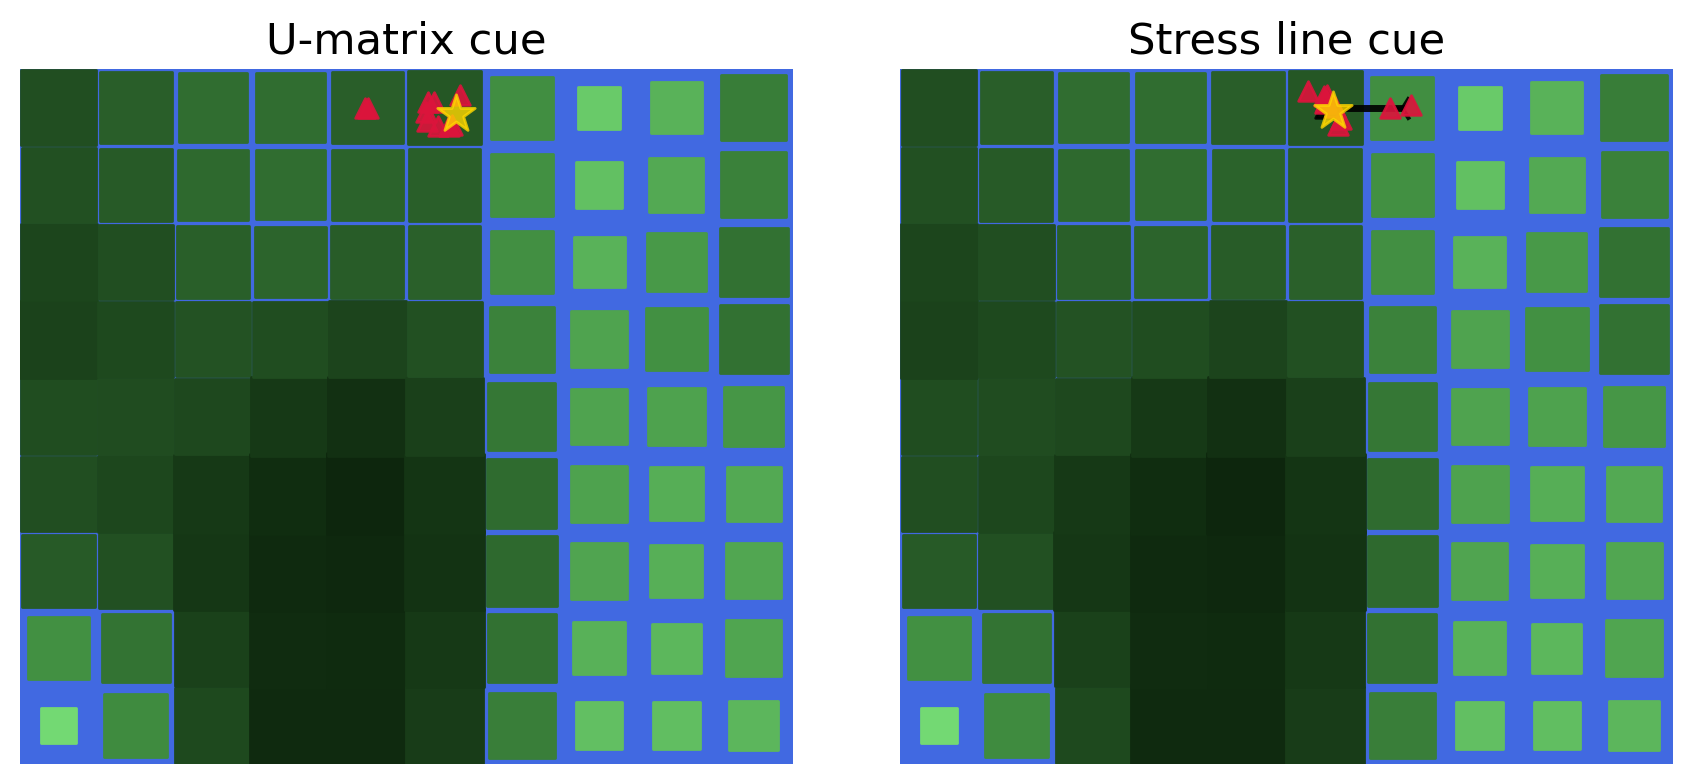

Figure saved to `_exports` folder as `05_Glass_sample_knn_queries.png`


In [11]:
for basin, dataset_name, x_idx, gap in zip(selected_basins, selected_datasets, selected_sample_inds, gaps):
	x = basin.data[x_idx]
	knn_projection_inds, knn_projection_altered_inds = get_knn_projections(basin.som, x_idx, k=10)

	figsize = (9, 4)
	coloring_strategy = "distance_map"

	pad_style = {
		"marker": "s",
		"gap": gap,
	}

	fig, (ax0, ax1) = plt.subplots(1, 2, figsize=figsize);

	rhizome_style = {
		"zorder": 11,
		"marker_start": "^",
		"marker_end": "3",
		"opacity": .9,
		"linewidth": 2.5,
	}

	attract_style_x = {
		"color": "gold",
		"label": dataset_name,
		"zorder": 22,
		"marker": "*",
		"size_base": 200,
		"opacity": .8,
		"subsample_ratio": None,
	}

	attract_style = {
		"color": "crimson",
		"label": dataset_name,
		"zorder": 21,
		"marker": "^",
		"size_base": 50,
		"opacity": .9,
		"subsample_ratio": None,
	}

	basin.pond() \
		.set_coloring_strategy(coloring_strategy) \
		.flood(below_activations=0) \
		.style_pad(**pad_style) \
		.style_petal(hide=True) \
		.style_flood(underwater_opacity=.4) \
		.style_rhizome(**rhizome_style) \
		.see_rhizome(mode="violating", ax=ax0) \
		.attract(basin.data[knn_projection_inds], **attract_style) \
		.attract(basin.data[[x_idx]], **attract_style_x) \
		.observe(return_fig=True, ax=ax0, title="U-matrix cue");

	basin.pond() \
		.set_coloring_strategy(coloring_strategy) \
		.flood(below_activations=0) \
		.style_pad(**pad_style) \
		.style_petal(hide=True) \
		.style_flood(underwater_opacity=.4) \
		.style_rhizome(**rhizome_style) \
		.see_rhizome(X=[x], mode="all", ax=ax1) \
		.attract(basin.data[knn_projection_altered_inds], **attract_style) \
		.attract(basin.data[[x_idx]], **attract_style_x) \
		.observe(return_fig=True, ax=ax1, title="Stress line cue");

	for ax in (ax0, ax1):
		ax.set_aspect('equal')
		ax.axis("off")

	plt.tight_layout()
	plt.show()

	# export fig
	from _utils.export import export_figure
	export_figure(fig, EXPORTS_DIR, f"05_{dataset_name}_sample_knn_queries.png", hide_titles=False)